In [ ]:
import osmnx as ox
place_name = 'Snohomish, Washington, USA' # Change this to switch cities
G = ox.graph_from_place(place_name, network_type='drive')
# Ensure the graph is strongly connected (guarantees a return path exists)
#G = ox.utils_graph.get_largest_component(G, strongly=True)



In [ ]:
start_node = list(G.nodes)[125]  # Arbitrary starting node
end_node = list(G.neighbors(start_node))[0]

In [ ]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [ ]:
len(G.nodes)

30917

In [ ]:
len(G.edges)

71455

In [ ]:
list(G.edges(data=True))[0]

(30139417,
 2304044269,
 {'osmid': 314941994,
  'highway': 'tertiary',
  'maxspeed': '30 mph',
  'name': '240th Street Southeast',
  'oneway': False,
  'reversed': False,
  'length': np.float64(103.79061701550403),
  'geometry': <LINESTRING (-122.18 47.78, -122.18 47.78, -122.179 47.78, -122.179 47.78)>})

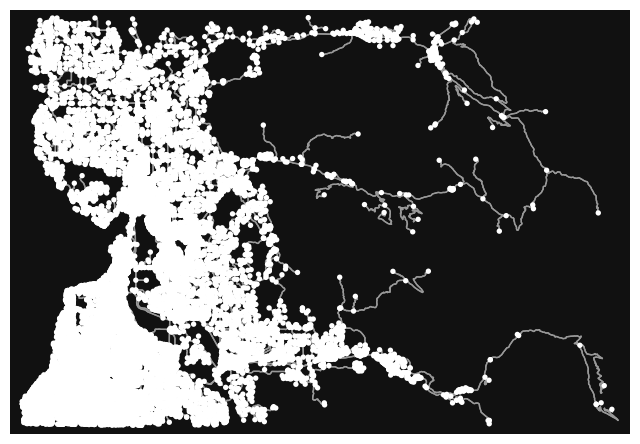

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(G)


In [ ]:
list(G.nodes(data=True))[0]

(30139417,
 {'y': 47.7800028, 'x': -122.180471, 'highway': 'stop', 'street_count': 3})

In [ ]:
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/aster30m?locations={locations}"
)
G = ox.elevation.add_node_elevations_google(G, batch_size=100, pause=1)
G = ox.elevation.add_edge_grades(G)
print(list(G.nodes(data=True))[0])
print(list(G.edges(data=True))[0])

(30139417, {'y': 47.7800028, 'x': -122.180471, 'highway': 'stop', 'street_count': 3, 'elevation': 26.0})
(30139417, 2304044269, {'osmid': 314941994, 'highway': 'tertiary', 'maxspeed': '30 mph', 'name': '240th Street Southeast', 'oneway': False, 'reversed': False, 'length': np.float64(103.79061701550403), 'geometry': <LINESTRING (-122.18 47.78, -122.18 47.78, -122.179 47.78, -122.179 47.78)>, 'grade': np.float64(0.17342608144733543), 'grade_abs': np.float64(0.17342608144733543)})


In [ ]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
print(gdf_nodes.shape)
print(gdf_edges.shape)
gdf_edges.head()

(30917, 9)
(71455, 18)


osmid      highway maxspeed  \
u        v          key                                                 
30139417 2304044269 0                 314941994     tertiary   30 mph   
         1194807327 0    [428033729, 428033727]    secondary   35 mph   
         136904439  0                 933078655     tertiary   30 mph   
30139423 1069646050 0                  92119192  residential      NaN   
         30139428   0                 992068879     tertiary      NaN   

                                           name  oneway reversed      length  \
u        v          key                                                        
30139417 2304044269 0    240th Street Southeast   False    False  103.790617   
         1194807327 0     39th Avenue Southeast   False     True   81.877399   
         136904439  0    240th Street Southeast   False     True  404.590873   
30139423 1069646050 0      30th Drive Southeast   False    False   93.216721   
         30139428   0           Fitzgerald Road   False    False  346.336204   

                                                                  geometry  \
u        v          key                                                      
30139417 2304044269 0    LINESTRING (-122.18047 47.78, -122.18041 47.78...   
         1194807327 0    LINESTRING (-122.18047 47.78, -122.18047 47.77...   
         136904439  0    LINESTRING (-122.18047 47.78, -122.18101 47.78...   
30139423 1069646050 0    LINESTRING (-122.19203 47.78105, -122.19183 47...   
         30139428   0    LINESTRING (-122.19203 47.78105, -122.19335 47...   

                            grade  grade_abs   lanes bridge  ref junction  \
u        v          key                                                     
30139417 2304044269 0    0.173426   0.173426     NaN    NaN  NaN      NaN   
         1194807327 0    0.048854   0.048854  [5, 4]    NaN  NaN      NaN   
         136904439  0   -0.029660   0.029660     NaN    NaN  NaN      NaN   
30139423 1069646050 0   -0.064366   0.064366     NaN    NaN  NaN      NaN   
         30139428   0    0.011549   0.011549     NaN    NaN  NaN      NaN   

                        access width tunnel area  
u        v          key                           
30139417 2304044269 0      NaN   NaN    NaN  NaN  
         1194807327 0      NaN   NaN    NaN  NaN  
         136904439  0      NaN   NaN    NaN  NaN  
30139423 1069646050 0      NaN   NaN    NaN  NaN  
         30139428   0      NaN   NaN    NaN  NaN

In [ ]:
gdf_edges.index[0]

(np.int64(30139417), np.int64(2304044269), np.int64(0))

In [ ]:
gdf_edges['maxspeed'].isnull().sum()

np.int64(60105)

In [ ]:
gdf_edges['highway'] = gdf_edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
print(gdf_edges['highway'].unique())
print(gdf_edges['highway'].isnull().sum())

<StringArray>
[      'tertiary',      'secondary',    'residential',  'living_street',
  'motorway_link',       'motorway',        'primary',   'primary_link',
   'unclassified',          'trunk',     'trunk_link',  'tertiary_link',
 'secondary_link']
Length: 13, dtype: str
0


<Axes: >

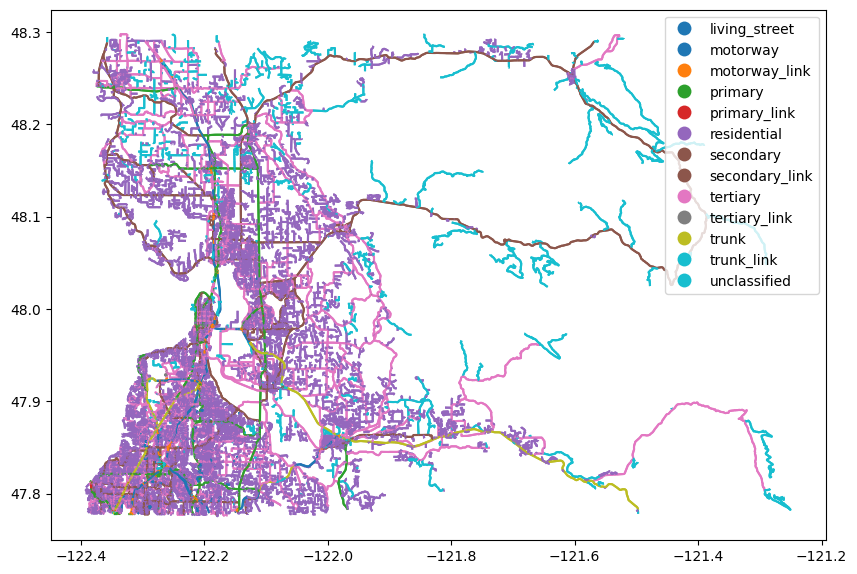

In [ ]:
gdf_edges.plot(column='highway', figsize=(10, 10), legend=True)

In [ ]:
default_speed = {
    'motorway': '60', 'motorway_link': '45', 'trunk': '55', 'trunk_link': '40',
    'primary': '45', 'primary_link': '40', 'secondary': '35', 'secondary_link': '30',
    'tertiary': '30', 'tertiary_link': '25', 'residential': '25', 'unclassified': '25', 'living_street': '10'
}

# Clean and convert maxspeed
import pandas as pd
# 1. Handle cases where 'highway' or 'maxspeed' is a list
gdf_edges['highway'] = gdf_edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].apply(lambda x: x[0] if isinstance(x, list) else x)

# 2. Force to string, strip ALL letters (mph, km/h), and convert to float
# pd.to_numeric with coerce safely turns empty strings into clean NaNs for the math
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(str).str.replace(r'\D+', '', regex=True)
gdf_edges['maxspeed'] = pd.to_numeric(gdf_edges['maxspeed'], errors='coerce')

# 3. Map your default dictionary (and ensure it applies them as floats)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(gdf_edges['highway'].map(default_speed).astype(float))

# 4. Fill any remaining weird OSM road types (like 'alley' or 'service') with 25
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(25)

# 5. Now that 100% of the NaNs are gone, it is completely safe to convert to integer!
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(int)

In [ ]:
gdf_edges['maxspeed'].isnull().sum()


np.int64(0)

In [ ]:
import shapely as shp
import math
help(math.atan2)

Help on built-in function atan2 in module math:

atan2(y, x, /)
    Return the arc tangent (measured in radians) of y/x.

    Unlike atan(y/x), the signs of both x and y are considered.



In [ ]:
from shapely import LineString


def compute_curvature(LineString):

    x, y = LineString.coords.xy
    currX = None
    currY = None
    bearing = 0
    prevbearing = None
    currbearing = None
    for n in range(len(x)):
        if n == 0:
            currX = x[n]
            currY = y[n]
        elif prevbearing is None:
            nextX = x[n]
            nextY = y[n]
            prevbearing = math.atan2(nextY - currY, nextX - currX)
            currX = nextX
            currY = nextY
        else:
            nextX = x[n]
            nextY = y[n]
            currbearing = math.atan2(nextY - currY, nextX - currX)
            diffBearing = abs(currbearing - prevbearing)
            diffBearing = min(diffBearing, math.pi)
            bearing = diffBearing - (math.pi*2) + bearing if diffBearing > math.pi else diffBearing + bearing
            prevbearing = currbearing
            currX = nextX
            currY = nextY

    return bearing
test_geom = gdf_edges['geometry'].iloc[0]
print(test_geom)
compute_curvature(test_geom)
for x in gdf_edges['geometry']:
    print(compute_curvature(x))
        

LINESTRING (-122.180471 47.7800028, -122.1804087 47.7800022, -122.1794657 47.7799935, -122.1790821 47.7799893)
0.0021277622856812877
0.00031028459469295555
0.0028499282824752115
1.8195699515625279
0.3849263725291603
1.0100983864431692
0.00020961173230377855
0.4699867820364081
0.3849263725291605
1.2901638686125305
0.9197373912884768
0.46998678203640853
0
7.2962441548345485
0.06402978187519381
0.9197373912884778
5.374893252209114
0.45378399831148397
0.3428978619683658
1.5896348379408685
0.19812713763622547
0.4832067029253191
1.1065608463543315
0
1.4657993713617978
5.7917438190311504e-05
0.004446533707558764
0.06223167573173327
0.043310351879514375
0.6046385091343924
1.4248992127828308
0.5412819733538529
0.1781210543342342
0.3493339835281124
0.16063776550977948
0.2904454513727514
3.5711925673366953
0.5919987160098423
0.998498839610912
0.29044545137275124
2.756335521187903
0.018867939709498988
0.00017710758979472274
0.04624320068704213
5.093607218465303
2.3570485479629255e-05
0.12431345015

In [ ]:
gdf_edges['curvature'] = gdf_edges['geometry'].apply(compute_curvature)
gdf_edges['curvature'].idxmax()

(np.int64(50608259), np.int64(50729315), np.int64(0))

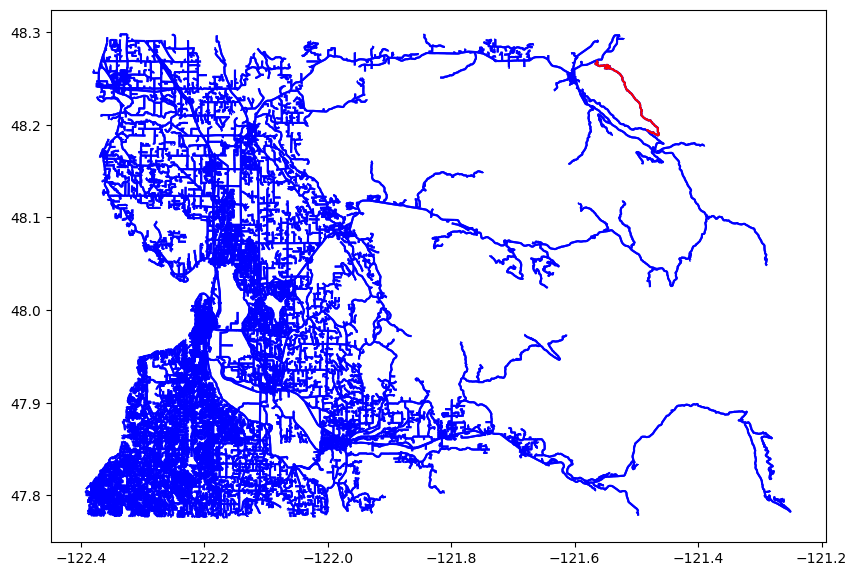

In [ ]:
import matplotlib.pyplot as plt
max_curve =gdf_edges[gdf_edges['curvature'] == gdf_edges['curvature'].max()]
fig, ax = plt.subplots(figsize=(10, 10))
gdf_edges.plot(ax =ax, color='blue', legend=True)
max_curve.plot(ax=ax, color='red', label='Max Curvature')
plt.show()




<Axes: >

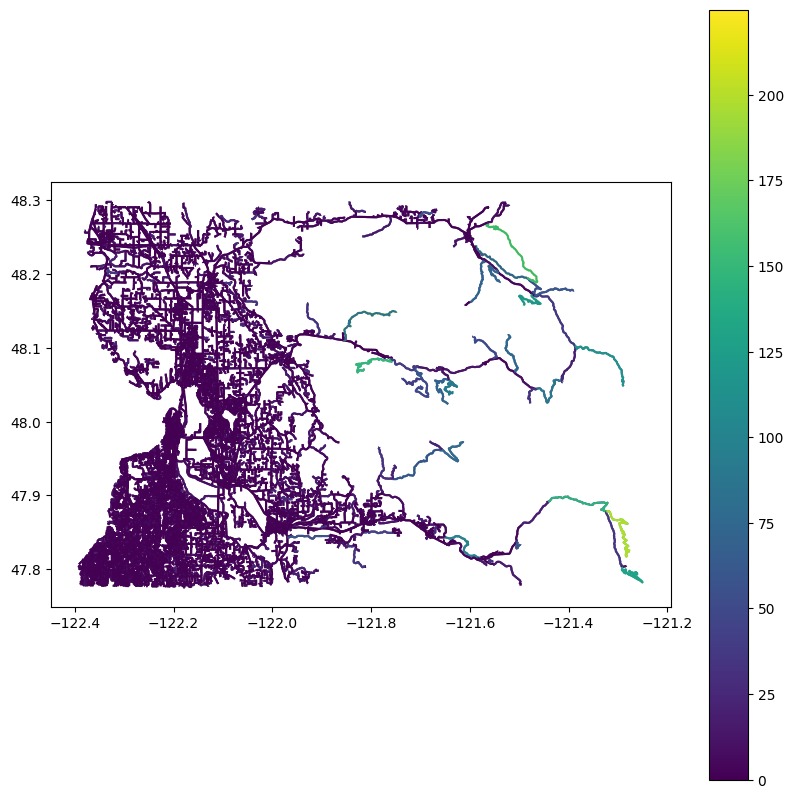

In [ ]:
gdf_edges.plot(column='curvature', figsize=(10, 10), legend=True)

In [ ]:
gdf_nodes.head()

,y,x,highway,street_count,elevation,ref,junction,railway,geometry
osmid,,,,,,,,,
30139417,47.780003,-122.180471,stop,3,26.0,NaN,NaN,NaN,POINT (-122.18047 47.78)
30139423,47.781047,-122.192030,NaN,3,26.0,NaN,NaN,NaN,POINT (-122.19203 47.78105)
30139428,47.783779,-122.194163,NaN,3,30.0,NaN,NaN,NaN,POINT (-122.19416 47.78378)
30139431,47.786048,-122.195738,NaN,3,39.0,NaN,NaN,NaN,POINT (-122.19574 47.78605)
30139437,47.788039,-122.197072,NaN,4,19.0,NaN,NaN,NaN,POINT (-122.19707 47.78804)


In [ ]:
gdf_edges.head()

osmid      highway  maxspeed  \
u        v          key                                                  
30139417 2304044269 0                 314941994     tertiary        30   
         1194807327 0    [428033729, 428033727]    secondary        35   
         136904439  0                 933078655     tertiary        30   
30139423 1069646050 0                  92119192  residential        25   
         30139428   0                 992068879     tertiary        30   

                                           name  oneway reversed      length  \
u        v          key                                                        
30139417 2304044269 0    240th Street Southeast   False    False  103.790617   
         1194807327 0     39th Avenue Southeast   False     True   81.877399   
         136904439  0    240th Street Southeast   False     True  404.590873   
30139423 1069646050 0      30th Drive Southeast   False    False   93.216721   
         30139428   0           Fitzgerald Road   False    False  346.336204   

                                                                  geometry  \
u        v          key                                                      
30139417 2304044269 0    LINESTRING (-122.18047 47.78, -122.18041 47.78...   
         1194807327 0    LINESTRING (-122.18047 47.78, -122.18047 47.77...   
         136904439  0    LINESTRING (-122.18047 47.78, -122.18101 47.78...   
30139423 1069646050 0    LINESTRING (-122.19203 47.78105, -122.19183 47...   
         30139428   0    LINESTRING (-122.19203 47.78105, -122.19335 47...   

                            grade  grade_abs   lanes bridge  ref junction  \
u        v          key                                                     
30139417 2304044269 0    0.173426   0.173426     NaN    NaN  NaN      NaN   
         1194807327 0    0.048854   0.048854  [5, 4]    NaN  NaN      NaN   
         136904439  0   -0.029660   0.029660     NaN    NaN  NaN      NaN   
30139423 1069646050 0   -0.064366   0.064366     NaN    NaN  NaN      NaN   
         30139428   0    0.011549   0.011549     NaN    NaN  NaN      NaN   

                        access width tunnel area  curvature  
u        v          key                                      
30139417 2304044269 0      NaN   NaN    NaN  NaN   0.002128  
         1194807327 0      NaN   NaN    NaN  NaN   0.000310  
         136904439  0      NaN   NaN    NaN  NaN   0.002850  
30139423 1069646050 0      NaN   NaN    NaN  NaN   1.819570  
         30139428   0      NaN   NaN    NaN  NaN   0.384926

In [ ]:
import pandas as pd
df_edges_matrix = gdf_edges[['length', 'maxspeed', 'grade','grade_abs', 'curvature','highway']]
df_highway_dummies = pd.get_dummies(df_edges_matrix['highway'], prefix='highway', drop_first =True)
df_edges_matrix.drop('highway', axis=1, inplace=True)
df_edges_matrix = pd.concat([df_edges_matrix, df_highway_dummies], axis=1)
print(df_edges_matrix.shape)
print(df_edges_matrix.isnull().sum())


(71455, 17)
length                    0
maxspeed                  0
grade                     0
grade_abs                 0
curvature                 0
highway_motorway          0
highway_motorway_link     0
highway_primary           0
highway_primary_link      0
highway_residential       0
highway_secondary         0
highway_secondary_link    0
highway_tertiary          0
highway_tertiary_link     0
highway_trunk             0
highway_trunk_link        0
highway_unclassified      0
dtype: int64


In [ ]:
for u, v, d in G.edges(data=True):
      print(u, v, d)
      break

30139417 2304044269 {'osmid': 314941994, 'highway': 'tertiary', 'maxspeed': '30 mph', 'name': '240th Street Southeast', 'oneway': False, 'reversed': False, 'length': np.float64(103.79061701550403), 'geometry': <LINESTRING (-122.18 47.78, -122.18 47.78, -122.179 47.78, -122.179 47.78)>, 'grade': np.float64(0.17342608144733543), 'grade_abs': np.float64(0.17342608144733543)}


In [ ]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs']


In [ ]:
G = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature']


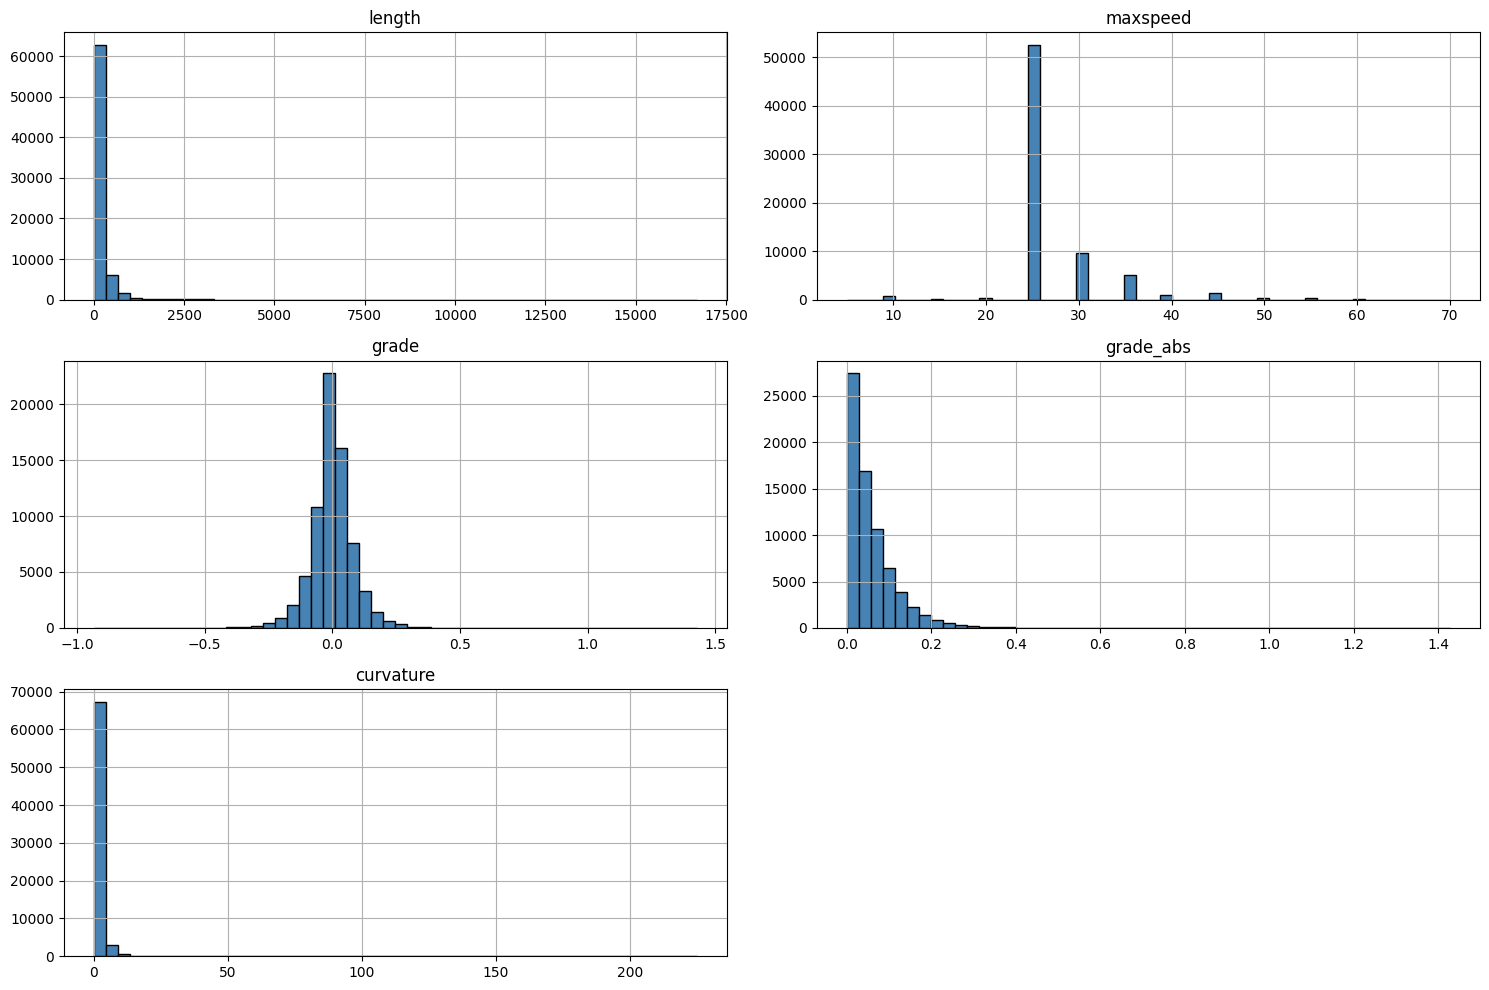

In [ ]:
df_edges_matrix.hist(
    figsize=(15, 10), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

# This prevents the subplot titles from overlapping
plt.tight_layout() 

plt.show()

<Axes: >

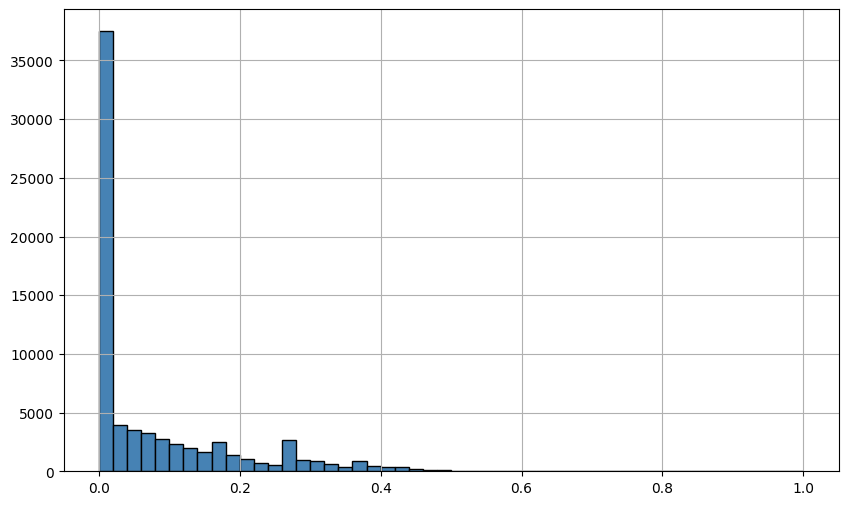

In [ ]:
import numpy as np
normalized_gdf_edges = gdf_edges.copy()
normalized_gdf_edges['curvature'] = np.log1p(normalized_gdf_edges['curvature'])
n_min = normalized_gdf_edges['curvature'].min()
n_max = normalized_gdf_edges['curvature'].max()
normalized_gdf_edges['curvature'] = (normalized_gdf_edges['curvature'] - n_min) / (n_max - n_min)
normalized_gdf_edges['curvature'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

70


<Axes: >

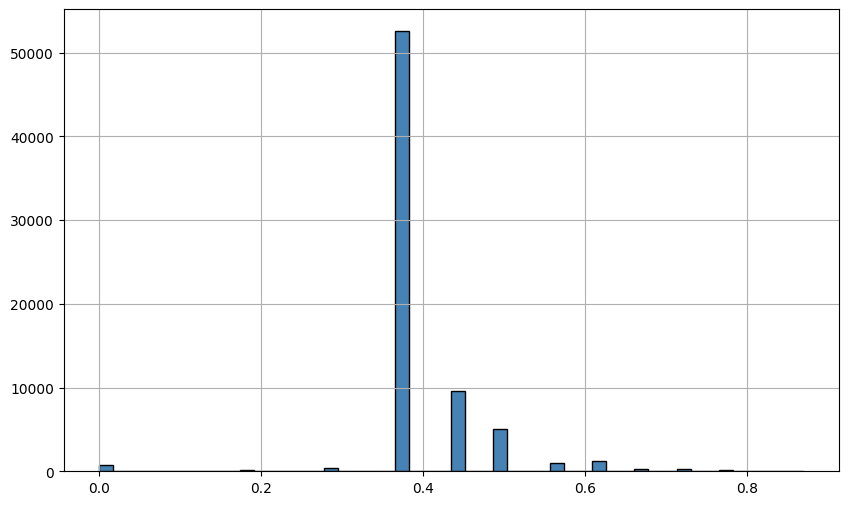

In [ ]:
# 10 is a minimum speed limit and 85 is a maximum speed limit
#0.625 gives an exponential distribution with 35mp being the center
print(normalized_gdf_edges['maxspeed'].max())
normalized_gdf_edges['maxspeed'] = ((normalized_gdf_edges['maxspeed'] - 10) / (85 - 10) )** 0.625 
normalized_gdf_edges['maxspeed'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

<Axes: >

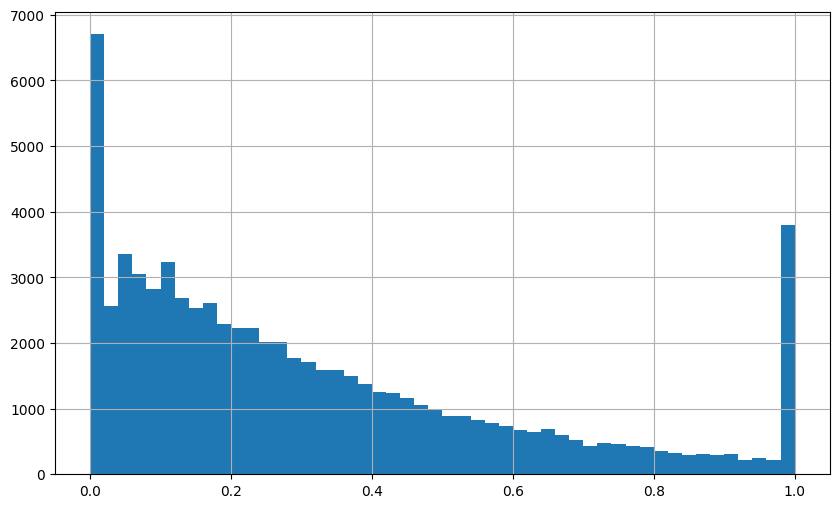

In [ ]:
lower_bounds = normalized_gdf_edges['grade_abs'].quantile(0.05)
higher_bounds = normalized_gdf_edges['grade_abs'].quantile(0.95)

normalized_gdf_edges['grade_abs'] = normalized_gdf_edges['grade_abs'].clip(lower=lower_bounds, upper=higher_bounds)
min_grade = normalized_gdf_edges['grade_abs'].min()
max_grade = normalized_gdf_edges['grade_abs'].max()
normalized_gdf_edges['grade_abs'] = (normalized_gdf_edges['grade_abs'] - min_grade) / (max_grade - min_grade)
normalized_gdf_edges['grade_abs'].hist(
    figsize=(10, 6),
    bins=50
)

<Axes: >

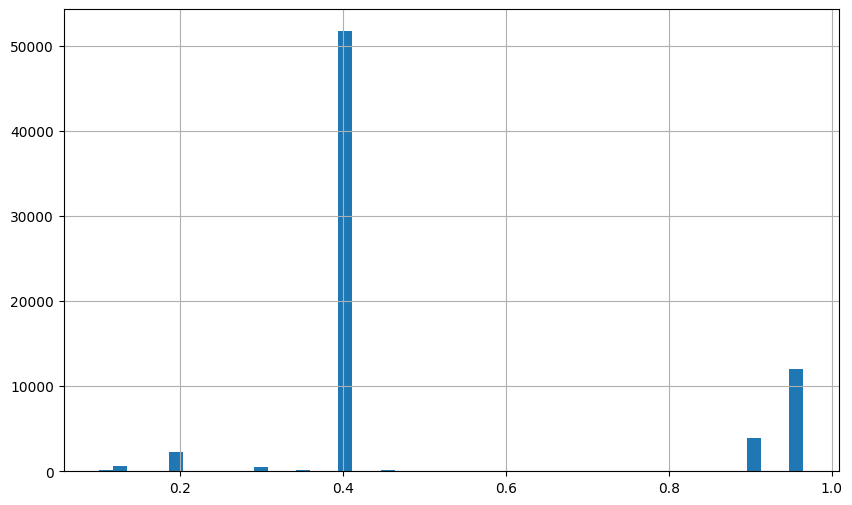

In [ ]:
highway_effectiveness = {
    # INTERSTATES & FREEWAYS: The highest capacity roads. Completely divided, no intersections.
    # Score: -0.6 (Severely penalized. Long, straight, boring, and full of semi-trucks.)
    'motorway': 0.1,       
    
    # ON/OFF RAMPS: The slip roads leading onto or off of a motorway.
    # Score: 0.2 (Sometimes a fun 270-degree sweeper, but too short to be the goal of a ride.)
    'motorway_link': 0.2,
    
    # MAJOR HIGHWAYS: Important divided roads, but slightly a step down from a full Interstate.
    # Score: 0.3 (High speed, but usually straight and heavily policed.)
    'trunk': 0.3,          
    
    # ON/OFF RAMPS for trunk roads.
    'trunk_link': 0.35,
    
    # ARTERIAL ROADS: Major roads linking large towns and cities together.
    # Score: 0.4 (Can be scenic, but usually have high traffic volume and stoplights.)
    'primary': 0.4,        
    
    # CONNECTORS for primary roads.
    'primary_link': 0.45,
    
    # REGIONAL ROADS: Medium-capacity roads linking smaller towns and villages.
    # Score: 0.9 (Great balance. Fast enough to be fun, rural enough to have sweeping curves, lower traffic.)
    'secondary': 0.9,      
    
    # CONNECTORS for secondary roads.
    'secondary_link': 0.85,
    
    # LOCAL CONNECTOR ROADS: Roads connecting smaller settlements or local districts.
    # Score: 0.8 (The "Sweet Spot" for twists. Often follow natural topography like rivers and hills.)
    'tertiary': 0.95,       
    
    # CONNECTORS for tertiary roads.
    'tertiary_link': 0.965,
    
    # NEIGHBORHOOD STREETS: Roads lined with houses and driveways.
    # Score: 0.4 (Lots of turns, but very low speed limits, stop signs, and kids playing.)
    'residential': 0.4,    
    
    # RURAL/MINOR ROADS: The lowest level of connecting road. Despite the name, it just means "local road".
    # Score: 0.55 (A gamble. Can be an amazing hidden canyon twisty, or a bumpy dirt road.)
    'unclassified': 0.2,  
    
    # PEDESTRIAN PRIORITY ZONES: Shared-space streets where pedestrians have the legal right of way.
    # Score: 0.12 (Extremely slow speed limits, actively avoiding these is a priority.)
    'living_street': 0.12  
}
normalized_gdf_edges['highway_effectiveness'] = normalized_gdf_edges['highway'].map(highway_effectiveness).fillna(0.5)
normalized_gdf_edges['highway_effectiveness'].hist(
    figsize=(10, 6),
    bins=50
)

In [ ]:
G = ox.graph_from_gdfs(gdf_nodes, normalized_gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
normalized_gdf_edges.head()

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature', 'highway_effectiveness']


osmid      highway  maxspeed  \
u        v          key                                                  
30139417 2304044269 0                 314941994     tertiary  0.437754   
         1194807327 0    [428033729, 428033727]    secondary  0.503268   
         136904439  0                 933078655     tertiary  0.437754   
30139423 1069646050 0                  92119192  residential  0.365716   
         30139428   0                 992068879     tertiary  0.437754   

                                           name  oneway reversed      length  \
u        v          key                                                        
30139417 2304044269 0    240th Street Southeast   False    False  103.790617   
         1194807327 0     39th Avenue Southeast   False     True   81.877399   
         136904439  0    240th Street Southeast   False     True  404.590873   
30139423 1069646050 0      30th Drive Southeast   False    False   93.216721   
         30139428   0           Fitzgerald Road   False    False  346.336204   

                                                                  geometry  \
u        v          key                                                      
30139417 2304044269 0    LINESTRING (-122.18047 47.78, -122.18041 47.78...   
         1194807327 0    LINESTRING (-122.18047 47.78, -122.18047 47.77...   
         136904439  0    LINESTRING (-122.18047 47.78, -122.18101 47.78...   
30139423 1069646050 0    LINESTRING (-122.19203 47.78105, -122.19183 47...   
         30139428   0    LINESTRING (-122.19203 47.78105, -122.19335 47...   

                            grade  grade_abs   lanes bridge  ref junction  \
u        v          key                                                     
30139417 2304044269 0    0.173426   0.991929     NaN    NaN  NaN      NaN   
         1194807327 0    0.048854   0.279423  [5, 4]    NaN  NaN      NaN   
         136904439  0   -0.029660   0.169641     NaN    NaN  NaN      NaN   
30139423 1069646050 0   -0.064366   0.368149     NaN    NaN  NaN      NaN   
         30139428   0    0.011549   0.066058     NaN    NaN  NaN      NaN   

                        access width tunnel area  curvature  \
u        v          key                                       
30139417 2304044269 0      NaN   NaN    NaN  NaN   0.000392   
         1194807327 0      NaN   NaN    NaN  NaN   0.000057   
         136904439  0      NaN   NaN    NaN  NaN   0.000525   
30139423 1069646050 0      NaN   NaN    NaN  NaN   0.191244   
         30139428   0      NaN   NaN    NaN  NaN   0.060080   

                         highway_effectiveness  
u        v          key                         
30139417 2304044269 0                     0.95  
         1194807327 0                     0.90  
         136904439  0                     0.95  
30139423 1069646050 0                     0.40  
         30139428   0                     0.95

In [ ]:

# Handle MultiDiGraph structure (dictionary of dictionaries)
def fun_score(u, v, d):
    # Handle MultiDiGraph structure (dictionary of dictionaries)
    if 0 in d:
        d = d[0]

    # Use .get(key, default) to safely handle missing data
    maxspeed = d.get('maxspeed', d.get('maxspeed', 0))
    grade = d.get('grade_abs_norm', d.get('grade_abs', 0))
    curvature = d.get('curvature', 0)
    penalty = d.get('highway_effectiveness', 1.0)

    score = (maxspeed * 0.1) + (grade * 0.1) + (curvature * 0.6) + (penalty * 0.2)

    

    return (1 - score) * d['length']
   
    

In [ ]:
import networkx as nx
u, v, key = gdf_edges.index[0]
nx.dijkstra_path(G, u, v, weight=fun_score)

[np.int64(30139417), np.int64(2304044269)]

In [ ]:
G.nodes[u]

{'y': 47.7800028,
 'x': -122.180471,
 'highway': 'stop',
 'street_count': 3,
 'elevation': 26.0}

In [ ]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
print(normalized_gdf_edges['curvature'].isnull().sum())
print(gdf_edges['curvature'].isnull().sum())
if normalized_gdf_edges['curvature'].isnull:
    print(normalized_gdf_edges['geometry'])
print(gdf_edges['curvature'].min())

['osmid', 'highway', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'grade', 'grade_abs', 'curvature', 'highway_effectiveness']
0
0
u           v           key
30139417    2304044269  0      LINESTRING (-122.18047 47.78, -122.18041 47.78...
            1194807327  0      LINESTRING (-122.18047 47.78, -122.18047 47.77...
            136904439   0      LINESTRING (-122.18047 47.78, -122.18101 47.78...
30139423    1069646050  0      LINESTRING (-122.19203 47.78105, -122.19183 47...
            30139428    0      LINESTRING (-122.19203 47.78105, -122.19335 47...
                                                     ...                        
50652617    5767502023  0      LINESTRING (-121.29229 47.80307, -121.29203 47...
            783648724   0      LINESTRING (-121.29229 47.80307, -121.29085 47...
783648724   50652617    0      LINESTRING (-121.28288 47.80494, -121.28305 47...
825410261   50619705    0      LINESTRING (-121.27696 47.82694, -121.27707 47...
5767502023  5

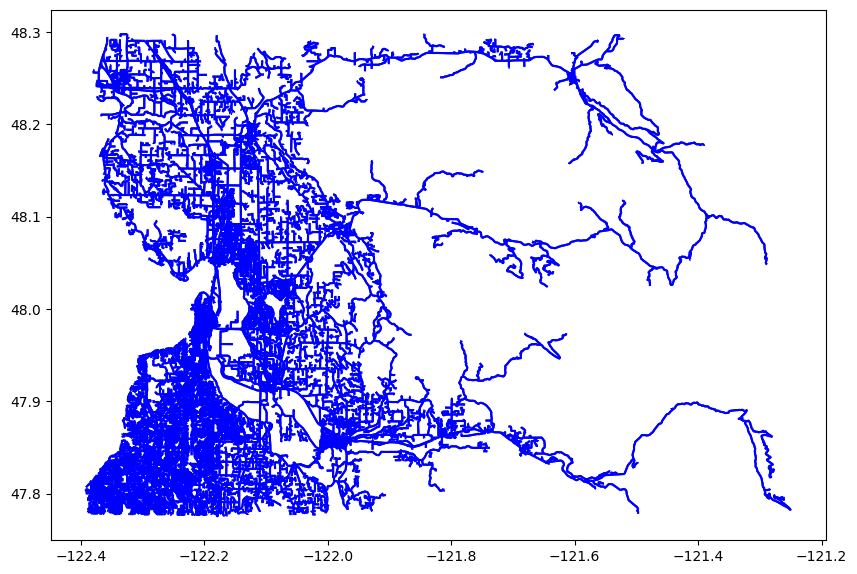

In [ ]:
null_curve = normalized_gdf_edges[normalized_gdf_edges['curvature'].isnull()]
fig, ax = plt.subplots(figsize=(10, 10))
normalized_gdf_edges.plot(ax=ax, color='blue', legend=True)

if not null_curve.empty:
	null_curve.plot(ax=ax, color='red', label='Null Curvature')

plt.show()

In [ ]:
distance, path = nx.single_source_dijkstra(G, u, cutoff= 100000, weight="length")
filter_distance_dict = {k: v for k, v in distance.items() if v >= 50000 and v < 100000}
print(filter_distance_dict)
len(filter_distance_dict)

{434869048: 50004.305601591164, 434864188: 50015.46508649354, 6972381993: 50025.10652958009, 50719146: 50042.37380667033, 50680528: 50042.44559176369, 5359205510: 50047.861935296925, 434870730: 50051.31381918296, 50813292: 50052.44839725737, 434938673: 50053.75713050018, 434868424: 50057.51940489445, 434940731: 50063.91647329772, 50610335: 50064.8137043534, 434900809: 50068.95245259243, 5412634003: 50074.623464824515, 6117373960: 50074.71509711138, 7331947459: 50077.53981635467, 50784051: 50077.640152918815, 50622318: 50079.19335716783, 6117450720: 50080.95278928253, 50679675: 50092.605322524585, 50688964: 50093.065399650826, 6888074401: 50093.51020577106, 50624526: 50095.80236554645, 5359205511: 50097.06651463148, 50774486: 50107.108225086944, 50700394: 50107.313687059366, 6117374209: 50112.4115303314, 50674091: 50114.6274688227, 434870755: 50120.732842537196, 50662522: 50122.02758478537, 50670154: 50130.879646266476, 3056811851: 50132.21940454384, 434868667: 50133.287891743064, 43489

2671

In [ ]:
nx.single_source_dijkstra(G, u, cutoff= 100000, weight="length")
distance_fun, path_fun = nx.single_source_dijkstra(G, u, weight=fun_score) 
dest = min(filter_distance_dict, key=lambda n: distance_fun[n]) 
print(path_fun[dest])

[30139417, 136904439, 13720878808, 50665134, 50696516, 50696518, 50639238, 1071136164, 1036617786, 50668298, 50696521, 50739879, 50739877, 6960560868, 1071208738, 50641690, 50641699, 50699302, 938216753, 50723361, 938216878, 50718567, 50615675, 50724835, 1009777605, 12564840159, 50748949, 6056867320, 1773299918, 4587655076, 50748951, 1773299911, 50748953, 286305524, 50674608, 7334240264, 3764362018, 50674609, 50674612, 50670621, 2358015951, 2358015971, 50655611, 5521319369, 5130057098, 2587323571, 50696495, 50696493, 2294875275, 50696491, 4626903443, 4626903451, 50644832, 1105699478, 1105699507, 1105699493, 50696489, 6902617305, 3116772754, 50640644, 50696486, 3222293132, 50633383, 1071714900, 1071714933, 50691843, 50696484, 2294784185, 5997597185, 50696478, 50696476, 50696474, 50696473, 50680373, 10824005758, 302496328, 302496634, 50755200, 5957660860, 1773178359, 50750358, 6787684532, 13822006045, 302497939, 302498145, 50675046, 1142326130, 1104222221, 286898761, 50793126, 50741786, 

In [ ]:
print(path_fun[dest])

[30139417, 136904439, 13720878808, 50665134, 50696516, 50696518, 50639238, 1071136164, 1036617786, 50668298, 50696521, 50739879, 50739877, 6960560868, 1071208738, 50641690, 50641699, 50699302, 938216753, 50723361, 938216878, 50718567, 50615675, 50724835, 1009777605, 12564840159, 50748949, 6056867320, 1773299918, 4587655076, 50748951, 1773299911, 50748953, 286305524, 50674608, 7334240264, 3764362018, 50674609, 50674612, 50670621, 2358015951, 2358015971, 50655611, 5521319369, 5130057098, 2587323571, 50696495, 50696493, 2294875275, 50696491, 4626903443, 4626903451, 50644832, 1105699478, 1105699507, 1105699493, 50696489, 6902617305, 3116772754, 50640644, 50696486, 3222293132, 50633383, 1071714900, 1071714933, 50691843, 50696484, 2294784185, 5997597185, 50696478, 50696476, 50696474, 50696473, 50680373, 10824005758, 302496328, 302496634, 50755200, 5957660860, 1773178359, 50750358, 6787684532, 13822006045, 302497939, 302498145, 50675046, 1142326130, 1104222221, 286898761, 50793126, 50741786, 

In [ ]:
return_path = nx.dijkstra_path(G,dest, u, weight=fun_score)
print(return_path)

[3791018873, 3791018895, 3791018931, 6687503011, 2272222812, 50765122, 50673982, 2272220010, 2272219999, 50656936, 50656947, 7384330128, 50789540, 50665726, 50612129, 50665713, 50665703, 50665695, 50663548, 2272146930, 50673713, 2670646561, 50673737, 50673743, 50673758, 50636696, 50673804, 50673811, 50668588, 50647323, 50673823, 50673825, 50673832, 50673842, 7103819641, 50673845, 2513530501, 50728098, 50728087, 50665279, 50728245, 50728217, 50728207, 50615056, 50728202, 50692453, 50814239, 50814237, 555101029, 50768103, 50712818, 50814233, 50744676, 50742071, 50739535, 6370340048, 50675317, 50701379, 50701380, 50701382, 50701384, 50701386, 50701387, 50701388, 50701390, 50701391, 50701393, 50682861, 50707251, 50633150, 50707219, 3199609455, 3276117174, 50662131, 50662096, 50727478, 1773220593, 7071544883, 1036541319, 1773220613, 50793136, 50738423, 50775897, 50792248, 50718015, 5997768165, 50768320, 50732299, 50732970, 50741786, 50793126, 286898761, 1104222221, 1142326130, 50675046, 302

In [ ]:
round_trip = path_fun[dest] + return_path[1:]
print(round_trip)

[30139417, 136904439, 13720878808, 50665134, 50696516, 50696518, 50639238, 1071136164, 1036617786, 50668298, 50696521, 50739879, 50739877, 6960560868, 1071208738, 50641690, 50641699, 50699302, 938216753, 50723361, 938216878, 50718567, 50615675, 50724835, 1009777605, 12564840159, 50748949, 6056867320, 1773299918, 4587655076, 50748951, 1773299911, 50748953, 286305524, 50674608, 7334240264, 3764362018, 50674609, 50674612, 50670621, 2358015951, 2358015971, 50655611, 5521319369, 5130057098, 2587323571, 50696495, 50696493, 2294875275, 50696491, 4626903443, 4626903451, 50644832, 1105699478, 1105699507, 1105699493, 50696489, 6902617305, 3116772754, 50640644, 50696486, 3222293132, 50633383, 1071714900, 1071714933, 50691843, 50696484, 2294784185, 5997597185, 50696478, 50696476, 50696474, 50696473, 50680373, 10824005758, 302496328, 302496634, 50755200, 5957660860, 1773178359, 50750358, 6787684532, 13822006045, 302497939, 302498145, 50675046, 1142326130, 1104222221, 286898761, 50793126, 50741786, 

In [ ]:
# .loc[row_label, column_label]
lat = gdf_nodes.loc[round_trip, 'y'].values
lon = gdf_nodes.loc[round_trip, 'x'].values
lat_lon = list(zip(lat, lon)) 
print(lat_lon)


[(np.float64(47.7800028), np.float64(-122.180471)), (np.float64(47.7800616), np.float64(-122.185885)), (np.float64(47.7832376), np.float64(-122.1860868)), (np.float64(47.7838257), np.float64(-122.1861249)), (np.float64(47.7855749), np.float64(-122.1862618)), (np.float64(47.7862831), np.float64(-122.1862827)), (np.float64(47.7874095), np.float64(-122.1863664)), (np.float64(47.7877593), np.float64(-122.1863914)), (np.float64(47.7889905), np.float64(-122.186463)), (np.float64(47.789308), np.float64(-122.1864849)), (np.float64(47.7911232), np.float64(-122.1865972)), (np.float64(47.7910525), np.float64(-122.1832847)), (np.float64(47.7910078), np.float64(-122.181215)), (np.float64(47.7929424), np.float64(-122.1811715)), (np.float64(47.7943574), np.float64(-122.1811341)), (np.float64(47.7950637), np.float64(-122.1811013)), (np.float64(47.7960603), np.float64(-122.1810655)), (np.float64(47.7967793), np.float64(-122.1810375)), (np.float64(47.79738), np.float64(-122.1810184)), (np.float64(47.798

In [ ]:
elliot_variations = normalized_gdf_edges.loc[
    normalized_gdf_edges['name'].str.contains("Elliot", na=False), 
    'name'
].unique()

print(elliot_variations)

['Elliott Road' 'Elliott Way' 'Elliott Brown Sr Place' 'Elliot Creek Road']


In [ ]:
elliot_rd = normalized_gdf_edges[normalized_gdf_edges['name'] == "Elliott Road"] 
print(elliot_rd.head())

                                          osmid   highway  maxspeed  \
u        v          key                                               
50656168 5220069648 0                  38689327  tertiary  0.503268   
         50735312   0                  38689327  tertiary  0.503268   
50665091 50764002   0                1236188880  tertiary  0.503268   
         50708579   0    [1236188880, 38689327]  tertiary  0.503268   
50668093 1946313968 0                  38689327  tertiary  0.503268   

                                 name  oneway reversed      length  \
u        v          key                                              
50656168 5220069648 0    Elliott Road   False    False  860.712597   
         50735312   0    Elliott Road   False     True  131.972352   
50665091 50764002   0    Elliott Road   False    False   15.896847   
         50708579   0    Elliott Road   False     True   92.114216   
50668093 1946313968 0    Elliott Road   False    False   85.941763   

           

In [ ]:
def fun_score_rows(d):
    # Handle MultiDiGraph structure (dictionary of dictionaries)
    if 0 in d:
        d = d[0]

    # Use .get(key, default) to safely handle missing data
    maxspeed = d.get('maxspeed', d.get('maxspeed', 0))
    grade = d.get('grade_abs_norm', d.get('grade_abs', 0))
    curvature = d.get('curvature', 0)
    penalty = d.get('highway_effectiveness', 1.0)

    score = (maxspeed * 0.1) + (grade * 0.1) + (curvature * 0.6) + (penalty * 0.2)

    

    return (1 - score) * d['length']

In [ ]:
current_winner = [(u,v, 0) for u, v in zip(round_trip, round_trip[1:])]
current_winner = normalized_gdf_edges.loc[current_winner]
current_winner['score'] = current_winner.apply(fun_score_rows, axis=1)
print(current_winner['score'].sum() / len(current_winner))

189.96396278955632


In [ ]:
elliot_rd['score'] = elliot_rd.apply(fun_score_rows, axis=1)
print(elliot_rd['score'].sum() / len(elliot_rd))


274.634189842974


In [ ]:
import folium
m = folium.Map(location=[47.9334204, -122.0823321], zoom_start=11)
folium.PolyLine(lat_lon, tooltip="Road").add_to(m)


In [ ]:
start_lon, start_lat = elliot_rd['geometry'].iloc[0].coords[0]

# 2. Loop through every single LineString in the geometry column
for line in elliot_rd['geometry']:
    
    # Extract the coordinates and flip them to (Latitude, Longitude) for Folium
    segment_coords = [(lat, lon) for lon, lat in line.coords]
    
    # 3. Draw this specific segment as its own independent line
    folium.PolyLine(
        locations=segment_coords,
        color='red',       # Give it a nice visible color
        weight=2,           # Make it thick enough to see easily
        opacity=0.8
    ).add_to(m)
m.save('round_trip_map.html')